In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.interpolate import interp1d

# Venus' Altitudinal Composition Variation

The pressure and temperature variations in Venus' atmosphere are given in ```GGchem/structures/VenusHighResFit.dat```.

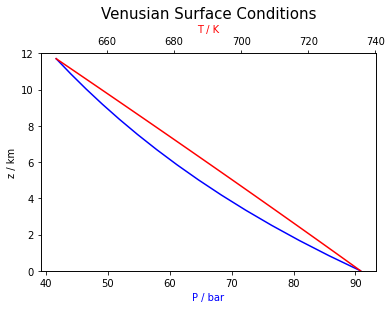

In [2]:
venus_structure = pd.read_csv('../GGchem/structures/VenusHighResFit.dat',
                              delim_whitespace=True,
                             index_col=0)[1:].set_index('z[km]')
max_alt_km = 12
venus_structure = venus_structure[venus_structure.index < max_alt_km]

fg, ax = plt.subplots()
ax2 = ax.twiny()

ax.plot(
    venus_structure['P[bar]'],
    venus_structure.index,
    c='b',
)
ax2.plot(
    venus_structure['T[K]'],
    venus_structure.index,
    c='r',
)

ax.set_xlabel('P / bar',
              color='b')
ax2.set_xlabel('T / K', color='r')
ax.set_ylabel('z / km')
ax.set_ylim([0,max_alt_km])
ax.set_title('Venusian Surface Conditions', fontsize=15);

The highest point on Venus' surface is Skadi Mons, at $12$km; the lowest is Diana Chasma, at $-2$km. The file goes from 0 to 250km, so we will make a new file to interpolate/extrapolate to Venus' surface conditions.

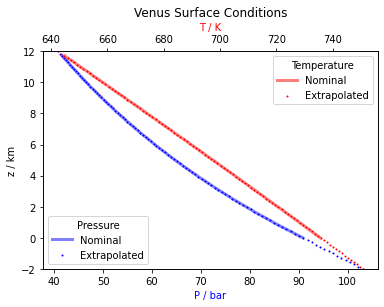

In [3]:
max_alt_km, npoints = 12, 100
# max_alt_km, npoints = 60, 1000 # For regions with no surface
z_km = np.linspace(-2,max_alt_km,npoints)
T_K = interp1d(venus_structure.index, venus_structure['T[K]'], fill_value='extrapolate'
              )(z_km)
P_bar = interp1d(venus_structure.index, venus_structure['P[bar]'], fill_value='extrapolate'
                )(z_km)

fg, ax = plt.subplots()
ax2 = ax.twiny()
ax.scatter(P_bar, z_km, c='b', s=1, label='Extrapolated')
ax.plot(venus_structure['P[bar]'], venus_structure.index,
        c='b', alpha=.5, lw=3, label='Nominal')
ax2.scatter(T_K,z_km,
            c='r', s=1, label='Extrapolated')
ax2.plot(venus_structure['T[K]'], venus_structure.index,
         c='r', alpha=.5, lw=3, label='Nominal')
ax.set_xlabel('P / bar', color='b')
ax2.set_xlabel('T / K', color='r')
ax.set_ylabel('z / km');
ax.set_ylim([-2, max_alt_km])
ax.set_title('Venus Surface Conditions')

ax.legend(loc='lower left', title='Pressure')
ax2.legend(loc='upper right', title='Temperature');

We now create a file like ```VenusHighResFit.dat```, but with these inter-/extrapolated $p$-$T$ profiles, so that GGchem can run on those conditions.

In [4]:
with open('../GGchem/structures/VenusHighResFit.dat', 'r') as f:
    text = f.read()

extrapolated_profile_filetext = text.split('\n')[0] + '\n' # Headers
extrapolated_profile_filetext += f' {int(len(z_km))}\n' # Number of rows

for i, (z, P, T) in enumerate(zip(z_km, P_bar, T_K)):
    extrapolated_profile_filetext += (' '*(4-len(str(i)))) + f'{str(i)} {z:e} {P:e} {T:e} \n'

with open('../GGchem/structures/VenusSurfaceExtrapFit.dat','w') as f:
    f.write(extrapolated_profile_filetext)

This input file will be used to run GGchem (note you must be in the GGchem folder to run things properly!). The output is put into ```StaticConc.dat```, which I have moved to ```venus/surface_results.dat```. We now look at the results.

In [5]:
# filename = f'./surface_results_high_alt.dat'
filename = f'./surface_results.dat'
# Extracting numbers of elements, molecules and condensates
data = open(filename)
_  = data.readline()
dimensions = data.readline()
dimens = np.array(dimensions.split(), dtype=int)
N_elements = dimens[0]
N_molecules = dimens[1]
N_condensates = dimens[2]
# Reading into df
df = pd.read_csv(
    filename,
    delim_whitespace=True,
    header=2,
    index_col=0
)
df['z[km]'] = z_km#[:100]
df = df.reset_index().set_index('z[km]')
df.head()

,Tg,nHges,pgas,el,H,C,N,O,F,S,...,epsMg,epsCa,epsAl,epsNa,epsK,epsTi,dust/gas,dustVol/H,Jstar(W),Nstar(W)
z[km],,,,,,,,,,,,,,,,,,,,,
-2.000000,750.6022,7.647086e+16,103049000.0,-300.0,3.157909,-28.167391,-10.526915,-5.270709,-3.695432,3.980908,...,-13.810203,-16.692483,-8.539696,-7.785978,-8.090612,-13.222403,3.345527,-15.165133,-300.0,999999.99999
-1.858586,749.5385,7.593699e+16,102184500.0,-300.0,3.139458,-28.213572,-10.575070,-5.328347,-3.743347,3.985889,...,-13.830727,-16.712909,-8.573381,-7.799557,-8.104894,-13.253180,3.345527,-15.165133,-300.0,999999.99999
-1.717172,748.4748,7.540159e+16,101320000.0,-300.0,3.120875,-28.260179,-10.623373,-5.386012,-3.791330,3.990469,...,-13.851273,-16.733390,-8.607075,-7.813163,-8.119207,-13.284029,3.345527,-15.165133,-300.0,999999.99999
-1.575758,747.4110,7.486461e+16,100455400.0,-300.0,3.102154,-28.307235,-10.671829,-5.443702,-3.839383,3.994625,...,-13.871844,-16.753929,-8.640776,-7.826798,-8.133550,-13.314953,3.345528,-15.165133,-300.0,999999.99999
-1.434343,746.3473,7.432617e+16,99590900.0,-300.0,3.083294,-28.354748,-10.720429,-5.501400,-3.887494,3.998332,...,-13.892436,-16.774522,-8.674473,-7.840459,-8.147921,-13.345947,3.345528,-15.165133,-300.0,999999.99999


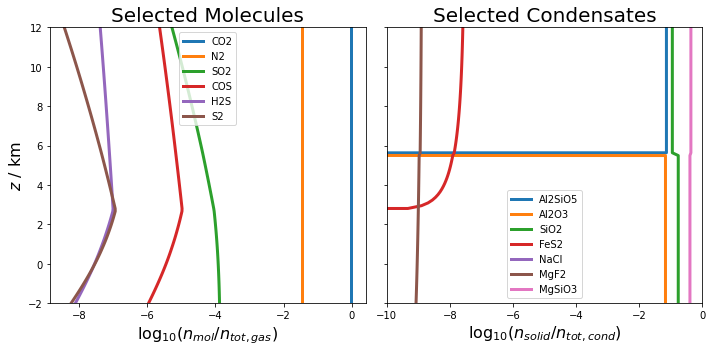

In [6]:
important_molecules = [
    'CO2','N2',
    'SO2','COS','H2S','S2',
#     'CO','H2O','H2','HCL','HF',#'Ar','Ne',
#     'H2SO4'
]
selected_condensates = [
    'Al2SiO5','Al2O3','SiO2',
#     'CaMgC2O6','MgCO3','Mg3Si4O12H2',
    'FeS2',
    'NaCl',
    'MgF2','MgSiO3',
#     'CaAl2Si2O8',
#     'NaAlSi3O8','KAlSi3O8','CaSO4',
#     'Fe2O3','Fe3O4','FeO',
#     'TiO2','Mn3Al2Si3O12'
]

def concentration(molecule, df, N_elements, N_molecules):
    """
    Returns the concentrations of a particular species, as a function of T, from a given df
    """
    return 10**(
        df[molecule] - np.log10(
            np.sum(
                10**df[
                    df.columns[3: 4+N_elements+N_molecules] # including e-, gaseous elements, gaseous molecules
                ],
                axis=1
            )
        )
    )
def condensed_mole_fraction(condensate, df, N_elements, N_molecules, N_condensates):
    """
    Returns the molar fractions of condensed species
    """
    return 10**(
        df[f'n{condensate}'] - np.log10(np.sum(10**df[df.columns[4+N_elements+N_molecules+N_condensates:
                                                                 4+N_elements+N_molecules+2*N_condensates]],
                                               axis=1
                                              )
                                       )
    )

fg, axs = plt.subplots(1,2,figsize=(10,5),
                      sharey=True)
ax = axs[0]
for molecule in important_molecules:
    concs = np.log10(concentration(molecule, df, N_elements, N_molecules))
    ax.plot(
        concs,
        df.index,
        label=molecule,
        lw=3
)
ax.legend(important_molecules, fontsize=10)
ax.set_xlabel('$\log_{10} (n_{mol} / n_{tot, gas})$', fontsize=16)
ax.set_ylabel('$z$ / km', fontsize=16);
ax.set_ylim([
    np.min(df.index.tolist()),
    np.max(df.index.tolist())
])
ax.set_title('Selected Molecules', fontsize=20)

ax = axs[1]
for i, condensate in enumerate(selected_condensates):
    concs = np.log10(condensed_mole_fraction(condensate, df, N_elements, N_molecules, N_condensates))
    ax.plot(
        concs,
        df.index,
        label=condensate,
        lw=3
    )
ax.legend(selected_condensates, fontsize=10)
ax.set_xlabel('$\log_{10} (n_{solid} / n_{tot, cond})$', fontsize=16)
ax.set_xlim([-10,0])
ax.set_ylim([
    np.min(df.index.tolist()),
    np.max(df.index.tolist())
])
ax.set_title('Selected Condensates', fontsize=20);
plt.tight_layout()

(-2.0, 12.0)

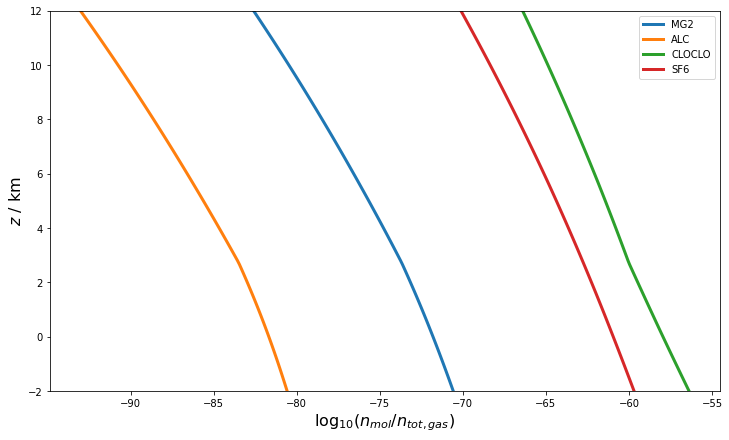

In [224]:
# all_species = df.columns[4:4+N_elements+N_molecules].tolist() +\
#               [col for col in df.columns if col[0]=='n']
all_species = ['MG2','ALC','CLOCLO','SF6','TICL4']
ranges = []
for species in all_species:
    ranges.append(np.ptp(df[species]))
tracer_species = np.array(all_species)[np.array(ranges)>10]
tracer_molecules = [mol for mol in tracer_species if mol[0]!='n']
fg, ax = plt.subplots(figsize=(12,7))
for molecule in tracer_molecules:
    concs = np.log10(concentration(molecule, df, N_elements, N_molecules))
    ax.plot(
        concs,
        df.index,
        label=molecule,
        lw=3
)
ax.legend(tracer_molecules, fontsize=10)
ax.set_xlabel('$\log_{10} (n_{mol} / n_{tot, gas})$', fontsize=16)
ax.set_ylabel('$z$ / km', fontsize=16);
ax.set_ylim([
    np.min(df.index.tolist()),
    np.max(df.index.tolist())
])

In [200]:
np.argmax(ranges)

348

In [201]:
all_species[348]

'nHges'